In [4]:
# Import data handling libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# Load the 4 CSV files from the raw data folder
student_info         = pd.read_csv('../data/raw/studentInfo.csv')
student_assessment   = pd.read_csv('../data/raw/studentAssessment.csv')
student_registration = pd.read_csv('../data/raw/studentRegistration.csv')
student_vle          = pd.read_csv('../data/raw/studentVle.csv')

# Print the shape (rows, columns) of each file to confirm loading
print(f"studentInfo shape:         {student_info.shape}")
print(f"studentAssessment shape:   {student_assessment.shape}")
print(f"studentRegistration shape: {student_registration.shape}")
print(f"studentVle shape:          {student_vle.shape}")

studentInfo shape:         (32593, 12)
studentAssessment shape:   (173912, 5)
studentRegistration shape: (32593, 5)
studentVle shape:          (10655280, 6)


In [6]:
# Explore the main file - studentInfo
# This file contains our target variable (final_result)
print("=== First 5 rows of studentInfo ===")
print(student_info.head())

print("\n=== Column names ===")
print(student_info.columns.tolist())

print("\n=== Data types of each column ===")
print(student_info.dtypes)

print("\n=== Missing values in each column ===")
print(student_info.isnull().sum())

=== First 5 rows of studentInfo ===
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1       

=== Target variable distribution ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

=== Percentage breakdown ===
final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64



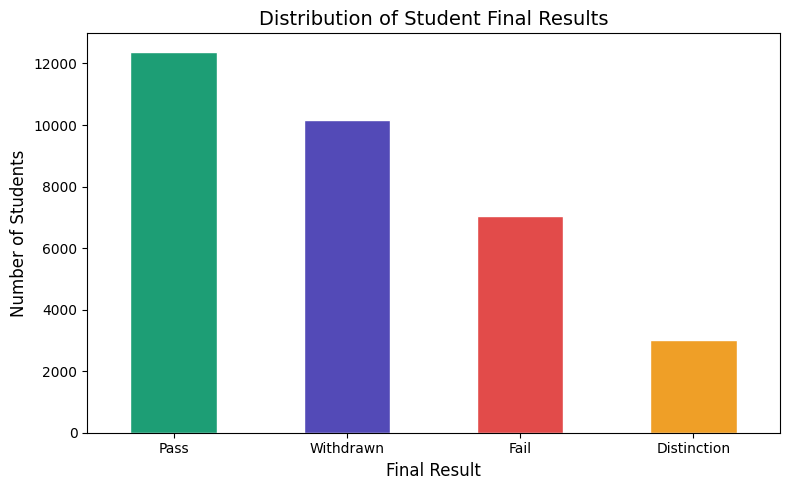

Chart saved to report folder


In [7]:
# Check the distribution of our target variable - final_result
print("=== Target variable distribution ===")
print(student_info['final_result'].value_counts())
print()

# Calculate percentage of each class
print("=== Percentage breakdown ===")
print(student_info['final_result'].value_counts(normalize=True) * 100)
print()

# Plot the distribution as a bar chart
plt.figure(figsize=(8, 5))
colors = ['#1D9E75', '#534AB7', '#E24B4A', '#EF9F27']
student_info['final_result'].value_counts().plot(
    kind='bar', 
    color=colors,
    edgecolor='white'
)
plt.title('Distribution of Student Final Results', fontsize=14)
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/01_target_distribution.png', dpi=150)
plt.show()
print("Chart saved to report folder")

In [8]:
# ── Quick EDA on studentAssessment ──────────────────────────
print("=== studentAssessment - first 3 rows ===")
print(student_assessment.head(3))
print(f"\nMissing values:\n{student_assessment.isnull().sum()}")
print(f"\nScore statistics:\n{student_assessment['score'].describe()}")

=== studentAssessment - first 3 rows ===
   id_assessment  id_student  date_submitted  is_banked score
0           1752       11391              18          0    78
1           1752       28400              22          0    70
2           1752       31604              17          0    72

Missing values:
id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64

Score statistics:
count     173912
unique       102
top          100
freq       18813
Name: score, dtype: object


In [9]:
# Diagnose the score column
print("Sample values in score column:")
print(student_assessment['score'].unique()[:20])
print()
print(f"Current dtype: {student_assessment['score'].dtype}")

Sample values in score column:
<StringArray>
['78', '70', '72', '69', '79', '71', '68', '73', '67', '83', '66', '59', '82',
 '60', '75', '74', '62', '63', '84', '80']
Length: 20, dtype: str

Current dtype: str


In [10]:
# Fix: score column is stored as StringArray dtype
# Need to convert to regular Python string first, then to number

student_assessment['score'] = student_assessment['score'].astype(str).replace('nan', np.nan)
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')

# Verify fix
print("=== Score column AFTER fixing ===")
print(student_assessment['score'].describe())
print()
print(f"Missing scores: {student_assessment['score'].isnull().sum()}")
print(f"dtype is now:   {student_assessment['score'].dtype}")

=== Score column AFTER fixing ===
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

Missing scores: 173
dtype is now:   float64


In [11]:
# Investigate the 173 missing score rows
missing_scores = student_assessment[student_assessment['score'].isnull()]

print(f"Total missing score rows: {len(missing_scores)}")
print()
print("=== Missing score rows - student IDs ===")
print(missing_scores[['id_student', 'id_assessment', 'date_submitted']].head(20))
print()

# Check what final_result these students have in studentInfo
missing_student_ids = missing_scores['id_student'].unique()
print(f"Unique students with missing scores: {len(missing_student_ids)}")
print()

# Cross check with studentInfo to see their final result
missing_students_info = student_info[
    student_info['id_student'].isin(missing_student_ids)
][['id_student', 'final_result']]

print("=== Final result of students with missing scores ===")
print(missing_students_info['final_result'].value_counts())

Total missing score rows: 173

=== Missing score rows - student IDs ===
       id_student  id_assessment  date_submitted
215        721259           1752              22
937        260355           1754             127
2364      2606802           1760             180
3358       186780          14984              77
3914       531205          14984              26
3943       534151          14984               7
4206       549713          14984              84
4311       554393          14984              55
4753       186780          14985              77
5722        33666          14986             117
6124       511527          14986             138
6527       554818          14986             146
7129       484039          14987             137
7574       554818          14987             150
7930       262294          14988             152
8517       554818          14988             158
8777       478317          14989             222
8847       502717          14989             2

In [13]:
# Create assessment features per student
print("Creating assessment features per student...")

assessment_features = student_assessment.groupby('id_student').agg(
    avg_score       = ('score', 'mean'),   # average score across all assessments
    total_score     = ('score', 'sum'),    # total marks earned
    submission_count= ('score', 'count')   # how many assessments submitted
).reset_index()

print(f"Assessment features shape: {assessment_features.shape}")
print()
print("=== Sample assessment features ===")
print(assessment_features.head())
print()
print("=== Missing values ===")
print(assessment_features.isnull().sum())

Creating assessment features per student...
Assessment features shape: (23369, 4)

=== Sample assessment features ===
   id_student  avg_score  total_score  submission_count
0        6516  61.800000        309.0                 5
1        8462  87.000000        609.0                 7
2       11391  82.000000        410.0                 5
3       23629  82.500000        330.0                 4
4       23698  74.444444        670.0                 9

=== Missing values ===
id_student           0
avg_score           18
total_score          0
submission_count     0
dtype: int64


In [14]:
# ── Quick EDA on studentRegistration ────────────────────────
print("=== studentRegistration - first 3 rows ===")
print(student_registration.head(3))
print(f"\nColumns: {student_registration.columns.tolist()}")
print(f"\nMissing values:\n{student_registration.isnull().sum()}")

print("\n" + "="*50 + "\n")

# ── Quick EDA on studentVle ──────────────────────────────────
print("=== studentVle - first 3 rows ===")
print(student_vle.head(3))
print(f"\nColumns: {student_vle.columns.tolist()}")
print(f"\nMissing values:\n{student_vle.isnull().sum()}")
print(f"\nClick statistics:\n{student_vle['sum_click'].describe()}")

=== studentRegistration - first 3 rows ===
  code_module code_presentation  id_student date_registration  \
0         AAA             2013J       11391              -159   
1         AAA             2013J       28400               -53   
2         AAA             2013J       30268               -92   

  date_unregistration  
0                   ?  
1                   ?  
2                  12  

Columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

Missing values:
code_module            0
code_presentation      0
id_student             0
date_registration      0
date_unregistration    0
dtype: int64


=== studentVle - first 3 rows ===
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1

Columns: ['code_module'